# Constrained Optimization

Minimize ‖p − target‖² subject to |p| = 2 using four gradient descent strategies.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from jaxcad.constraints import (
    DistanceConstraint,
    extract_free_dof,
    linearize_at,
    project_gradient,
    project_to_manifold,
)
from jaxcad.geometry import Vector

## Setup

p₀ = (2, 0, 0), target = (1, 1.5, 0). `run` times N steps after a warm-up call to exclude JAX compilation.

In [ ]:
anchor = Vector(jnp.array([0.0, 0.0, 0.0]), free=False, name="anchor")
p = Vector(jnp.array([2.0, 0.0, 0.0]), free=True, name="p")

constraints = [DistanceConstraint(p, anchor, 2.0)]
param_list = [p]
target = jnp.array([1.0, 1.5, 0.0])
x0 = jnp.array([2.0, 0.0, 0.0])

N_STEPS = 40
LAMBDA = 25.0

optimizer = optax.adam(learning_rate=0.05)


def objective(full):
    return jnp.sum((full - target) ** 2)


def constraint_res(full):
    return jnp.array([jnp.linalg.norm(full) - 2.0])


def violation(full):
    return float(jnp.abs(jnp.linalg.norm(full) - 2.0))


def run(grad_fn, opt=optimizer, x_init=x0, post_step=None, n=N_STEPS):
    """grad_fn(full) -> (val, grad). opt and state are owned by run."""
    opt_state = opt.init(x_init)
    grad_fn(x_init)  # warm-up
    hist = {"loss": [], "violation": [], "cumtime": [], "traj": [np.array(x_init)]}
    t0, full = time.perf_counter(), x_init
    for _ in range(n):
        val, g = grad_fn(full)
        updates, opt_state = opt.update(g, opt_state)
        full = full + updates
        if post_step is not None:
            full = post_step(full)
        hist["loss"].append(float(val))
        hist["violation"].append(violation(full))
        hist["cumtime"].append(time.perf_counter() - t0)
        hist["traj"].append(np.array(full))
    return hist, full


p_star = 2.0 * target / jnp.linalg.norm(target)
optimal_loss = float(objective(p_star))
print(f"analytic optimum: {np.array(p_star).round(4)},  loss = {optimal_loss:.6f}")

## Fixed null-space projection

N computed once at x₀; gradient projected onto NNᵀ each step.

In [3]:
_, N_fixed = extract_free_dof(constraints, param_list)


def grad_1a(full):
    val, g = jax.value_and_grad(objective)(full)
    return val, project_gradient(g, N_fixed)


h_1a, end_1a = run(grad_1a)
print(f"1a  loss={h_1a['loss'][-1]:.4f}  violation={h_1a['violation'][-1]:.2e}")

1a  loss=1.0001  violation=5.02e-01


## Relinearized null-space projection

N recomputed at the current point each step. Adam runs in the 2D reduced (tangent) space — moment estimates stay in a consistent low-dimensional frame. The rotating null-space basis introduces O(lr) misalignment per step (equivalent to ignoring parallel transport in Riemannian Adam), which is acceptable for small lr. Violation still accumulates because steps along the tangent plane depart the curved manifold by O(lr²κ) with no correction.

In [4]:
def grad_1b(full):
    _, N = linearize_at(full, constraints, param_list)
    val, g = jax.value_and_grad(objective)(full)
    return val, project_gradient(g, N)


h_1b, end_1b = run(grad_1b)
print(f"1b  loss={h_1b['loss'][-1]:.4f}  violation={h_1b['violation'][-1]:.2e}")

1b  loss=0.1743  violation=5.52e-01


## Projected gradient descent

Unconstrained step, then `project_to_manifold`: one Newton correction Δ = Jᵀ(JJᵀ)⁻¹r(p) that snaps the point back to the manifold. For the sphere this is exact; for general nonlinear constraints it is first-order accurate.

In [5]:
def grad_2(full):
    return jax.value_and_grad(objective)(full)


h_2, end_2 = run(
    grad_2,
    post_step=lambda full: project_to_manifold(full, constraints, param_list),
)
print(f"2   loss={h_2['loss'][-1]:.4f}  violation={h_2['violation'][-1]:.2e}")

2   loss=0.0389  violation=0.00e+00


## Penalty method

Augmented loss: ‖p − t‖² + λ‖r(p)‖². Penalty Hessian eigenvalue in the normal direction is 2 + 2λ; stable LR ≤ 1/(1 + 2λ).

In [6]:
LR_PENALTY = 0.9 / (1.0 + 2.0 * LAMBDA)  # LR < 1/(1 + 2λ)
optimizer_penalty = optax.adam(learning_rate=LR_PENALTY)


def loss_penalty(full):
    return objective(full) + LAMBDA * jnp.sum(constraint_res(full) ** 2)


def grad_3(full):
    true_val = float(objective(full))
    _, g = jax.value_and_grad(loss_penalty)(full)
    return true_val, g


h_3, end_3 = run(grad_3, opt=optimizer_penalty)
print(f"3   loss={h_3['loss'][-1]:.4f}  violation={h_3['violation'][-1]:.2e}")

3   loss=1.4138  violation=3.47e-02


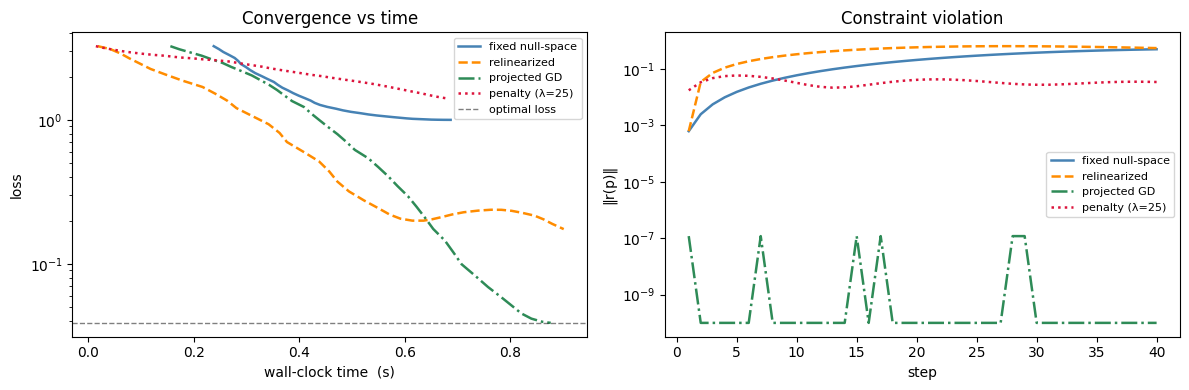

In [7]:
STYLES = {
    "fixed null-space": (h_1a, "steelblue", "-", "o"),
    "relinearized": (h_1b, "darkorange", "--", "s"),
    "projected GD": (h_2, "seagreen", "-.", "^"),
    f"penalty (λ={LAMBDA:.0f})": (h_3, "crimson", ":", "D"),
}

FLOOR = 1e-10  # clip exact zeros so log scale doesn't break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for label, (h, color, ls, _) in STYLES.items():
    ax.semilogy(h["cumtime"], h["loss"], color=color, linestyle=ls, lw=1.8, label=label)
ax.axhline(optimal_loss, color="black", ls="--", lw=1, alpha=0.5, label="optimal loss")
ax.set_xlabel("wall-clock time  (s)")
ax.set_ylabel("loss")
ax.set_title("Convergence vs time")
ax.legend(fontsize=8)

ax = axes[1]
for label, (h, color, ls, _) in STYLES.items():
    v = [max(x, FLOOR) for x in h["violation"]]
    ax.semilogy(range(1, len(v) + 1), v, color=color, linestyle=ls, lw=1.8, label=label)
ax.set_xlabel("step")
ax.set_ylabel("‖r(p)‖")
ax.set_title("Constraint violation")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

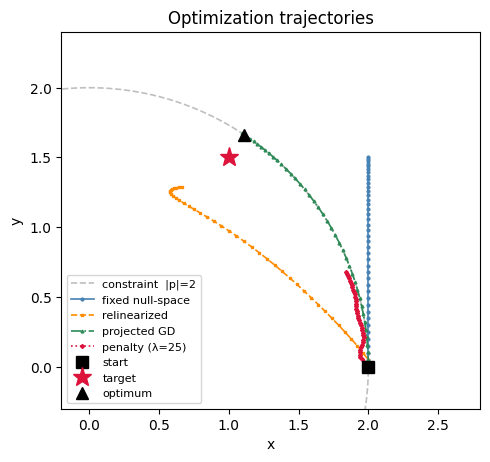

In [8]:
theta = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(
    2 * np.cos(theta),
    2 * np.sin(theta),
    "--",
    color="gray",
    alpha=0.5,
    lw=1.2,
    label="constraint  |p|=2",
)

for label, (h, color, ls, marker) in STYLES.items():
    traj = np.array(h["traj"])
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        color=color,
        linestyle=ls,
        marker=marker,
        markersize=2,
        lw=1.2,
        label=label,
    )

ax.plot(*x0[:2], "s", color="black", ms=9, zorder=6, label="start")
ax.plot(*np.array(target)[:2], "*", color="crimson", ms=14, zorder=6, label="target")
ax.plot(*np.array(p_star)[:2], "^", color="black", ms=9, zorder=6, label="optimum")
ax.set_xlim(-0.2, 2.8)
ax.set_ylim(-0.3, 2.4)
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("Optimization trajectories")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()